<a href="https://colab.research.google.com/github/Ritesh-Gawande/Machine-Learning-Code/blob/main/Kmeans_AgeIncome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
data = {
    'Age': [22, 25, 23, 45, 46, 48, 35, 36, 38],
    'Income': [25, 30, 28, 65, 68, 70, 40, 42, 45]
}

In [40]:
df = pd.DataFrame(data)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Age     9 non-null      int64
 1   Income  9 non-null      int64
dtypes: int64(2)
memory usage: 276.0 bytes


In [6]:
df.head()

,Student,Math Score,Science Score
0,A,2,3
1,B,3,4
2,C,3,5
3,D,8,7
4,E,9,8


In [7]:
df.describe()

,Math Score,Science Score
count,6.000000,6.000000
mean,5.833333,6.000000
std,3.544949,2.366432
min,2.000000,3.000000
25%,3.000000,4.250000
50%,5.500000,6.000000
75%,8.750000,7.750000
max,10.000000,9.000000


In [18]:
df.drop('Student',axis=1,inplace=True)

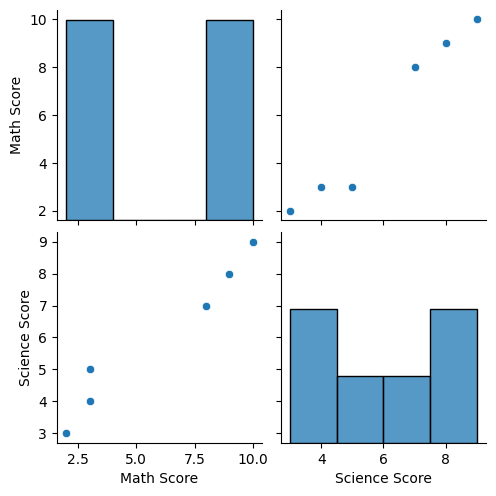

In [8]:
sns.pairplot(df)

<Axes: ylabel='Count'>

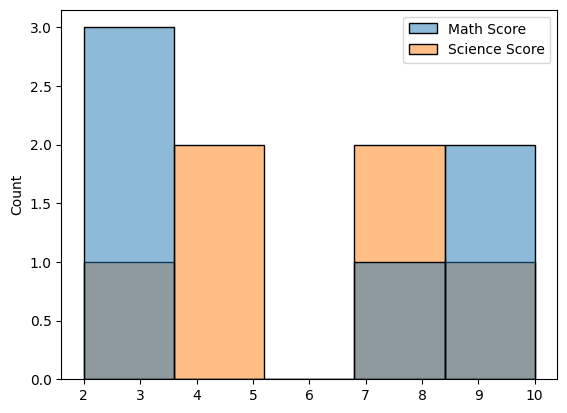

In [9]:
sns.histplot(df)

In [42]:
df

,Age,Income
0,22,25
1,25,30
2,23,28
3,45,65
4,46,68
5,48,70
6,35,40
7,36,42
8,38,45


In [55]:
from sklearn.preprocessing import StandardScaler
Sc = StandardScaler()
df = Sc.fit_transform(df)
df

array([[-1.40372481, -1.25461649],
       [-1.08788673, -0.95430935],
       [-1.29844545, -1.0744322 ],
       [ 1.01770049,  1.14784062],
       [ 1.12297985,  1.3280249 ],
       [ 1.33353857,  1.44814775],
       [-0.03509312, -0.35369507],
       [ 0.07018624, -0.23357222],
       [ 0.28074496, -0.05338794]])

In [56]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

In [57]:
df

array([[-1.40372481, -1.25461649],
       [-1.08788673, -0.95430935],
       [-1.29844545, -1.0744322 ],
       [ 1.01770049,  1.14784062],
       [ 1.12297985,  1.3280249 ],
       [ 1.33353857,  1.44814775],
       [-0.03509312, -0.35369507],
       [ 0.07018624, -0.23357222],
       [ 0.28074496, -0.05338794]])

In [58]:
kmeans.fit(df)

KMeans(n_clusters=3, random_state=42)

In [60]:
kmeans.labels_

array([1, 1, 1, 0, 0, 0, 2, 2, 2], dtype=int32)

In [53]:
print(kmeans.cluster_centers_)

[[46.33333333 67.66666667]
 [23.33333333 27.66666667]
 [36.33333333 42.33333333]]


In [54]:
new = [[24,27]]
pred = kmeans.predict(new)
pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

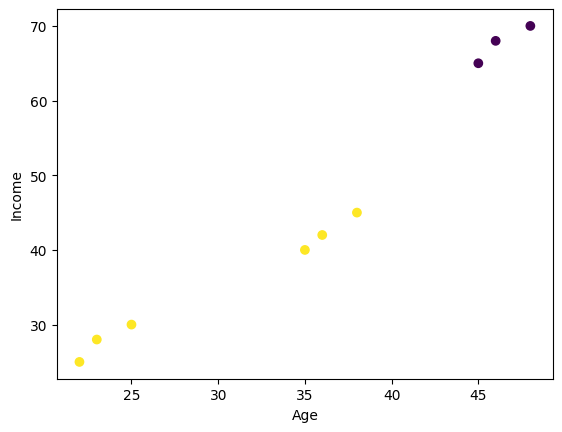

In [48]:
plt.scatter(df['Age'],df['Income'],c=kmeans.labels_)
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()